# MODELIZACION PARA CLASIFICACION

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import classification_report

#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
import scikitplot as skplt
#from yellowbrick.classifier import discrimination_threshold

#Autocompletar rapido
%config IPCompleter.greedy=True

#Desactivar la notacion cientifica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

In [2]:
ruta_proyecto = 'C:/Users/vifra/vidal cientifico de datos/Portafolio ML/Proyecto leadscoring/00_PROYECTO_LEADSCORING/'

In [3]:
nombre_x = 'x_preseleccionado.pickle'
nombre_y = 'y_preseleccionado.pickle'

In [4]:
x = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_x)
y = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_y)

In [5]:
x

,tiempo_en_site_total_mms,score_actividad_mms,score_perfil_mms,ocupacion_Working Professional,ult_actividad_SMS Sent,visitas_total_mms,paginas_vistas_visita_mms,ambito_Select,ult_actividad_Chat Conversation,ult_actividad_Page Visited on Website,ult_actividad_Converted to Lead,descarga_lm_No,origen_Lead Add Form
id,,,,,,,,,,,,,
660737,0.00,0.73,0.44,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00
660728,0.30,0.73,0.44,0.00,0.00,0.10,0.16,1.00,0.00,0.00,0.00,1.00,0.00
660727,0.67,0.64,1.00,0.00,0.00,0.04,0.12,0.00,0.00,0.00,0.00,0.00,0.00
660719,0.13,0.55,0.67,0.00,0.00,0.02,0.06,0.00,0.00,0.00,0.00,1.00,0.00
660681,0.63,0.73,0.78,0.00,0.00,0.04,0.06,1.00,0.00,0.00,1.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
579564,0.81,0.73,0.67,0.00,0.00,0.16,0.17,0.00,0.00,0.00,0.00,1.00,0.00
579546,0.10,0.64,0.89,0.00,1.00,0.04,0.12,0.00,0.00,0.00,0.00,0.00,0.00
579545,0.09,0.55,1.00,0.00,1.00,0.04,0.12,0.00,0.00,0.00,0.00,0.00,0.00


## MODELIZAR

### Reservar el dataset de validacion

In [6]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Creacion del pipe y el diccionario de algorimos, parametros y valores a testiar

Modificar para dejar solo los algoritmos que se quieran testar.

Modificar los parametros.

In [7]:
pipe = Pipeline([('algoritmo',RandomForestClassifier())])

grid = [{'algoritmo': [LogisticRegression()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__solver': ['saga'],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2', 'none'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]},
        
       ]

### Optimizar los hiper parametros

Elegir si se quiere usar grid search o random search.

Comentar la opcion que no se vaya a usar.

####  Con grid search

In [8]:
 grid_search = GridSearchCV(estimator= pipe, 
                            param_grid = grid, 
                            cv = 3, 
                            scoring = 'roc_auc',
                            verbose = 0,
                            n_jobs = -1)

 modelo = grid_search.fit(train_x,train_y)

 pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__n_jobs,param_algoritmo__penalty,param_algoritmo__solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
19,0.03,0.00,0.00,0.00,LogisticRegression(),1,-1,none,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.01,1
15,0.04,0.01,0.01,0.00,LogisticRegression(),0.75,-1,none,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.01,2
11,0.04,0.01,0.00,0.00,LogisticRegression(),0.50,-1,none,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.01,2
7,0.05,0.00,0.01,0.00,LogisticRegression(),0.25,-1,none,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.01,4
17,0.04,0.00,0.00,0.00,LogisticRegression(),1,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,5
13,0.04,0.01,0.01,0.00,LogisticRegression(),0.75,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,6
9,0.04,0.01,0.01,0.00,LogisticRegression(),0.50,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,7
18,0.03,0.00,0.00,0.00,LogisticRegression(),1,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,8
5,0.05,0.00,0.01,0.00,LogisticRegression(),0.25,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,9
14,0.03,0.00,0.01,0.00,LogisticRegression(),0.75,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.87,0.88,0.87,0.87,0.00,10


## EVALUAR

### Predecir sobre validacion

In [9]:
pred = modelo.best_estimator_.predict_proba(val_x)[:, 1]

### Evaluar sobre validacion

In [10]:
roc_auc_score(val_y, pred)

0.8807190060798309

### Examinar el mejor modelo

In [11]:
modelo.best_estimator_

Pipeline(steps=[('algoritmo',
                 LogisticRegression(C=1, n_jobs=-1, penalty='none',
                                    solver='saga'))])

## REPORTING DEL MODELO

### Gain Chart

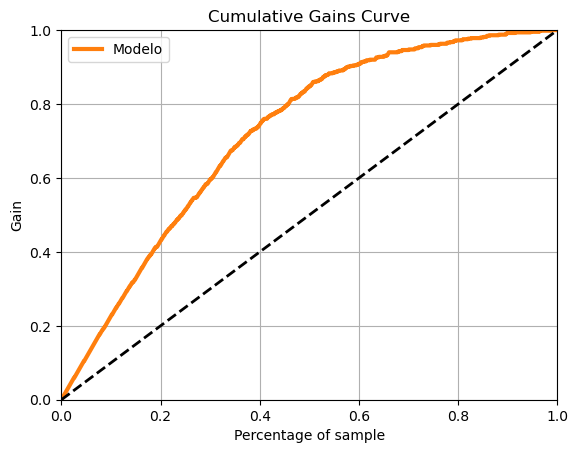

In [12]:
fig, ax = plt.subplots()

skplt.metrics.plot_cumulative_gain(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la linea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la linea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la linea de los ceros
plt.legend(labels=['Modelo'])

# Grafico
plt.show()

### Lift Chart

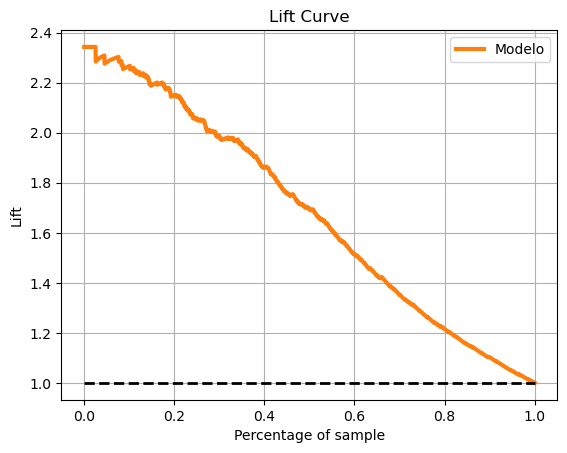

In [13]:
fig, ax = plt.subplots()

skplt.metrics.plot_lift_curve(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la linea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la linea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la linea de los ceros
plt.legend(labels=['Modelo'])

# Grafico
plt.show()

### ROC Chart

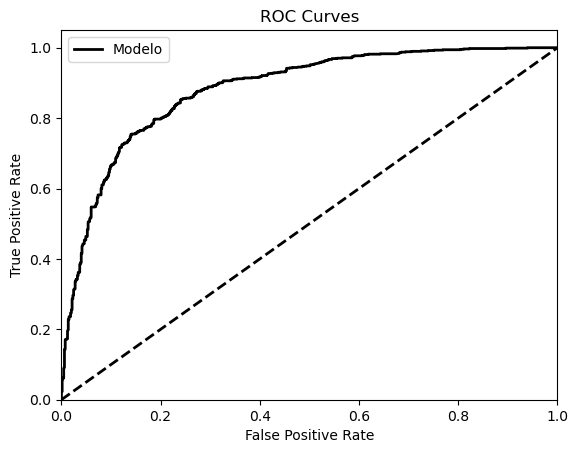

In [14]:
fig, ax = plt.subplots()

# Generamos la grafica ROC
skplt.metrics.plot_roc(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Obtenemos todas las lineas y las leyendas
lines = ax.get_lines()

# Recorremos las lineas para eliminar las no deseadas, excepto la linea de la clase 0
for line in lines:
    if 'ROC curve of class 0' in line.get_label():
        line.set_label('Modelo')
    elif line.get_linestyle() != '--':  # Mantenemos la linea punteada pero sin leyenda
        line.set_visible(False)

# Solo añadimos al leyenda la línea de la clase 0 renombrada a 'Modelo'
handles, labels = ax.get_legend_handles_labels()
new_handles = [h for h, l in zip(handles, labels) if l == 'Modelo']
new_labels = ['Modelo']

ax.legend(new_handles, new_labels, loc='best')

# Grafico
plt.show();
